## DBSCAN Clustering
### `Density-Based Spatial Clustering of Applications with Noise`

#### What is DBSCAN?

**DBSCAN** is a clustering algorithm that finds groups based on **density** — regions where data points are packed closely together.

Unlike K-Means, DBSCAN:
- Does **not** require you to specify the number of clusters beforehand
- Can find clusters of **any shape** (not just spherical shaped)
- Automatically labels scattered, isolated points as **noise/outliers**

---

## DBSCAN vs K-Means — Key Differences

| Feature | K-Means | DBSCAN |
|---------|---------|--------|
| Number of clusters | You must specify k | Found automatically |
| Cluster shape | Only round/spherical | Any shape |
| Outliers | Forced into a cluster | Labelled as noise (−1) |
| Parameters | `n_clusters` | `eps` and `min_samples` |
| Best for | Compact, well-separated blobs | Irregular shapes, noisy data |

---

## How DBSCAN Works — Three Types of Point

DBSCAN classifies every point into one of three categories using **two** parameters:

- **`eps`** — the search radius around each point ("how far to look")
- **`min_samples`** — the minimum number of neighbours needed to form a dense region

```
CORE POINT   → has at least min_samples neighbours within eps distance
               These are the "heart" of a cluster.

BORDER POINT → has fewer than min_samples neighbours,
               but lies within eps of a core point.
               On the edge of a cluster.

NOISE POINT  → not a core point and not near any core point.
               Treated as an outlier. Labelled -1 by sklearn.
```

**The algorithm:**
1. Pick an unvisited point
2. Count its neighbours within `eps`
3. If ≥ `min_samples` → it's a core point, start a cluster and expand outward
4. Keep expanding until no more core points can be reached
5. Repeat for remaining unvisited points
6. Any point never reached = noise

---
## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("Libraries imported.")

Libraries imported.


## Step 2 - Create a Realistic Dataset

We will use a **delivery driver dataset**. Each row is one driver, described by:
- `deliveries_per_day` — average number of deliveries made daily
- `avg_distance_km` — average distance driven per delivery

The data has three natural driver types, plus some scattered outliers (unusual drivers that don't fit any group).

This is a good scenario for DBSCAN because:
- We don't know in advance how many groups exist
- Outliers (e.g. part-time or long-haul specialists) should be flagged, not forced into a cluster

In [3]:
# Build the dataset
# Three natural groups of drivers + scattered outliers

rng = np.random.default_rng(42)

# Group 1 — City drivers: many deliveries, short distances
city = rng.normal([22, 3],  scale=[2, 0.5], size=(80, 2))

# Group 2 — Suburban drivers: moderate deliveries, medium distances
suburban = rng.normal([12, 10], scale=[2, 1],   size=(70, 2))

# Group 3 — Rural drivers: few deliveries, long distances
rural = rng.normal([5,  22],  scale=[1, 2],   size=(50, 2))

# Outliers — unusual drivers scattered across the space
outliers = rng.uniform([0, 0], high=[30, 30], size=(20, 2))

# Combine everything into a DataFrame
data = np.vstack([city, suburban, rural, outliers])
df = pd.DataFrame(data.clip(min=0), columns=['deliveries_per_day', 'avg_distance_km'])

print(f"Dataset: {df.shape[0]} drivers, {df.shape[1]} features")


Dataset: 220 drivers, 2 features


In [6]:
#city.astype(int)

**explaining code for dataset production above**

```
rng = np.random.default_rng(42)
Creates a random number generator with seed 42. The seed ensures you get the same data every time you run the code — making results reproducible.

city = rng.normal([22, 3], scale=[2, 0.5], size=(80, 2))
Generates 80 city drivers. rng.normal draws from a normal distribution:

[22, 3] — the mean of each feature: average 22 deliveries/day, average 3 km/delivery
scale=[2, 0.5] — the spread (standard deviation): deliveries vary by ±2, distances by ±0.5
size=(80, 2) — produce an 80-row, 2-column array (80 drivers, 2 features each)

The same logic applies to suburban and rural — just different means and spreads to represent different driver behaviours.

outliers = rng.uniform(low=[0, 0], high=[30, 30], size=(20, 2))

Generates 20 outlier drivers using a uniform distribution — every value between 0 and 30 is equally likely. This deliberately scatters them randomly across the whole data space, rather than clustering them around a specific mean. These represent unusual drivers that don't belong to any natural group.

data = np.vstack([city, suburban, rural, outliers])
np.vstack stacks the four arrays vertically — one on top of the other — combining them into a single array of shape (220, 2) containing all 220 drivers.

df = pd.DataFrame(data.clip(min=0), columns=['deliveries_per_day', 'avg_distance_km'])

Two things happen here:

.clip(min=0) — the normal distribution can occasionally produce negative numbers (e.g. a driver with −0.3 km distance). Clipping forces any negative value up to 0, keeping the data physically realistic.
pd.DataFrame(...) — wraps the numpy array in a pandas DataFrame and assigns proper column names so the features are easy to refer to.

```

In [7]:
df.describe().round(2)

,deliveries_per_day,avg_distance_km
count,220.00,220.00
mean,14.08,10.73
std,7.38,7.96
min,0.16,1.08
25%,6.61,3.12
50%,12.77,9.52
75%,21.28,19.26
max,29.41,27.32


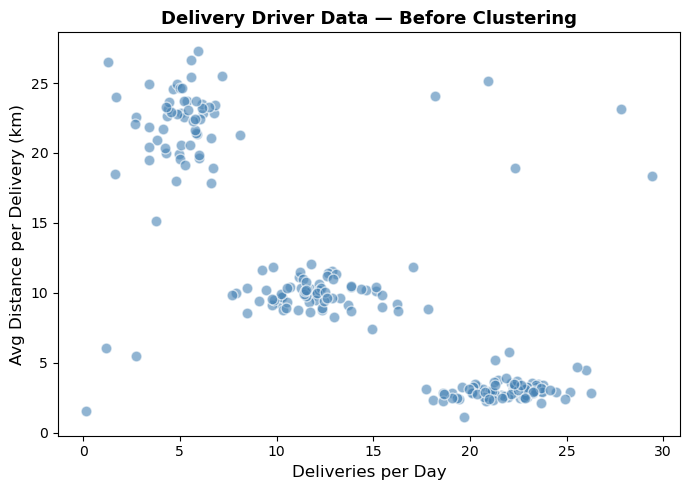

In [8]:
# Plot the raw unlabelled data
# This is what we see BEFORE clustering

plt.figure(figsize=(7, 5))
plt.scatter(df['deliveries_per_day'], df['avg_distance_km'],
            color='steelblue', alpha=0.6, edgecolors='white', s=60)
plt.xlabel('Deliveries per Day', fontsize=12)
plt.ylabel('Avg Distance per Delivery (km)', fontsize=12)
plt.title('Delivery Driver Data — Before Clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 3 — Scale the Data

DBSCAN, like K-Means, uses **distance** to find neighbours. If one feature has much larger values than another, it will unfairly dominate the distance calculation.

`StandardScaler` puts both features on the same scale: **mean = 0, std = 1**.

In [9]:
# Scale both features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("After scaling:")
print(f"  Mean : {X_scaled.mean(axis=0).round(3)}")
print(f"  Std  : {X_scaled.std(axis=0).round(3)}")

After scaling:
  Mean : [ 0. -0.]
  Std  : [1. 1.]


---
## Step 4 — Choose eps Using the k-Distance Plot

The two parameters we must set are:

**`min_samples`** — a good starting rule of thumb: use **2 × number of features**. With 2 features, `min_samples = 5` is a sensible default. `A point needs 4 neighours to form a cluster hence min_samples = 5`

**`eps`** — harder to choose by intuition. The **k-distance plot** helps:

1. For each point, compute its distance to its `k`-th nearest neighbour (where `k = min_samples`)
2. Sort these distances and plot them
3. Look for the **elbow** — the sharp bend in the curve
4. The distance at the elbow is your `eps`

**Why the elbow?** Points to the left of the elbow are in dense regions (short distances to neighbours). Points to the right are in sparse regions. The elbow marks where density transitions from dense to sparse — which is exactly the boundary DBSCAN should use.

In [11]:
# Compute the distance from each point to its 5th nearest neighbour
# (using min_samples = 5)

k = 5
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_scaled)

# distances shape: (n_points, k)
# We want the k-th neighbour distance → column index k-1
distances, _ = nn.kneighbors(X_scaled)
kth_distances = np.sort(distances[:, k - 1])   # sort ascending

In [17]:
kth_distances[:10]

array([0.0217949 , 0.02271281, 0.02362307, 0.0250911 , 0.02755382,
       0.02755382, 0.02910798, 0.03035712, 0.03335067, 0.03386217])

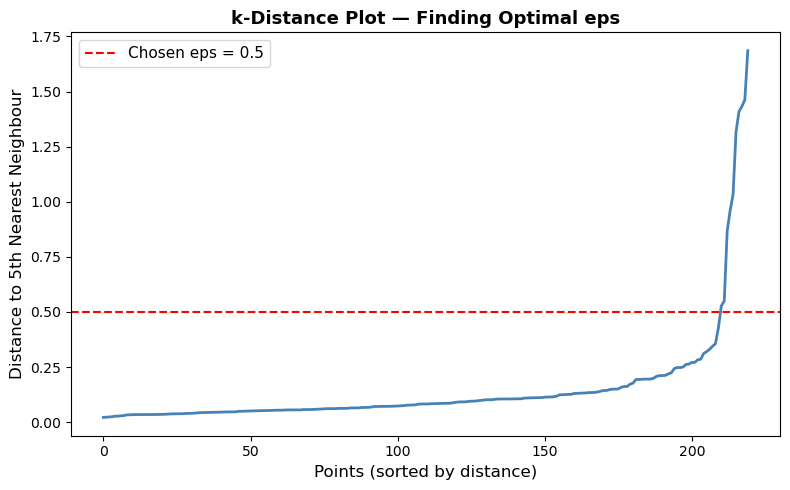

Look for the sharp bend (elbow) in the curve.
The distance at the elbow is a good choice for eps.


In [12]:
# Plot the k-distance graph
# The elbow shows the best eps value

plt.figure(figsize=(8, 5))
plt.plot(kth_distances, color='steelblue', linewidth=2)

# Mark our chosen eps with a horizontal dashed line
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Chosen eps = 0.5')

plt.xlabel('Points (sorted by distance)', fontsize=12)
plt.ylabel(f'Distance to {k}th Nearest Neighbour', fontsize=12)
plt.title('k-Distance Plot — Finding Optimal eps', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Look for the sharp bend (elbow) in the curve.")
print("The distance at the elbow is a good choice for eps.")

## Step 5 - Fit DBSCAN

Now we fit the model using the `eps` and `min_samples` values we chose.

`fit_predict()` fits the model and returns a **label for every point**:
- `0, 1, 2, …` — cluster numbers
- `-1` — noise/outlier (not assigned to any cluster)

In [13]:
# Fit DBSCAN
# eps=0.5  → search radius (in scaled units)
# min_samples=5 → a point needs 5 neighbours within eps to be a core point

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Summary of what was found
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise}")
print(f"\nLabel counts:")
for label in sorted(set(labels)):
    name = 'Noise' if label == -1 else f'Cluster {label}'
    print(f"  {name:<12}: {(labels == label).sum()} points")

Clusters found : 3
Noise points   : 8

Label counts:
  Noise       : 8 points
  Cluster 0   : 84 points
  Cluster 1   : 70 points
  Cluster 2   : 58 points


## Step 6 — Visualise the DBSCAN Results

We plot each cluster in a different colour. **Noise points** (label = −1) are shown as small grey crosses so they stand out clearly.

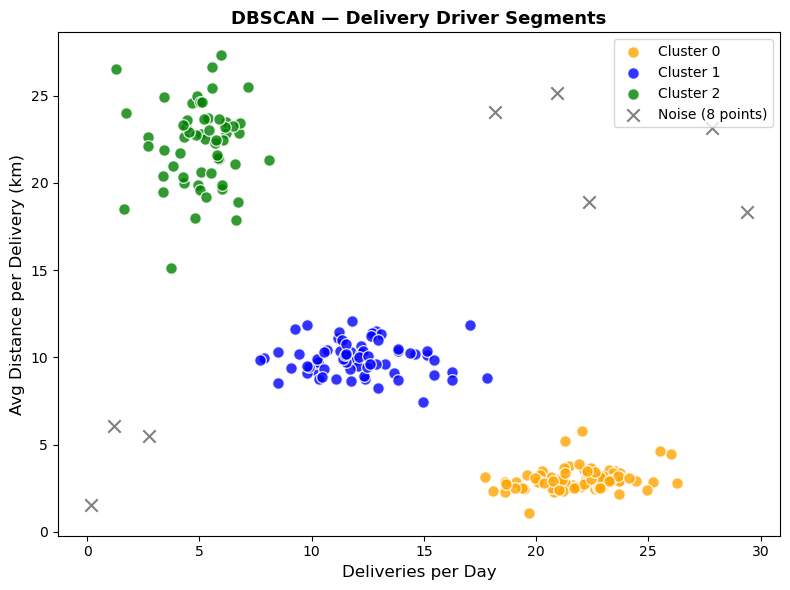

In [14]:
# Add labels back to the original (unscaled) DataFrame for easy plotting
df['cluster'] = labels

# Colour palette — one colour per cluster, grey for noise
cluster_colours = {0: 'orange', 1: 'blue', 2: 'green', 3: 'grey'} 

plt.figure(figsize=(8, 6))

# Plot each cluster
for cluster_id, colour in cluster_colours.items():
    mask = df['cluster'] == cluster_id
    if mask.sum() > 0:
        plt.scatter(df.loc[mask, 'deliveries_per_day'],
                    df.loc[mask, 'avg_distance_km'],
                    c=colour, label=f'Cluster {cluster_id}',
                    s=70, alpha=0.8, edgecolors='white')

# Plot noise points separately
noise_mask = df['cluster'] == -1
plt.scatter(df.loc[noise_mask, 'deliveries_per_day'],
            df.loc[noise_mask, 'avg_distance_km'],
            c='grey', marker='x', s=80, linewidths=1.5,
            label=f'Noise ({noise_mask.sum()} points)')

plt.xlabel('Deliveries per Day', fontsize=12)
plt.ylabel('Avg Distance per Delivery (km)', fontsize=12)
plt.title('DBSCAN — Delivery Driver Segments', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Explaining the code above**

```
df['cluster'] = labels
Adds the DBSCAN output (the array of cluster numbers like [0, 1, -1, 2, ...]) as a new column in the DataFrame. 

cluster_colours = {0: 'orange', 1: 'blue', 2: 'green', 3: 'grey'}
A dictionary mapping each cluster number to a colour. When we loop through the clusters, we look up the colour for each one here.

for cluster_id, colour in cluster_colours.items():
Loops through the dictionary. On each iteration cluster_id is the cluster number (0, 1, 2…) and colour is the corresponding colour string.

mask = df['cluster'] == cluster_id
Creates a boolean mask — a True/False series the same length as the DataFrame. True for every row belonging to the current cluster, False for all others. This is how we select only the rows for one cluster at a time.

if mask.sum() > 0:
mask.sum() counts how many True values there are (i.e. how many points are in this cluster). The if guard prevents trying to plot an empty cluster, which would cause an error.

plt.scatter(df.loc[mask, 'deliveries_per_day'],df.loc[mask, 'avg_distance_km'],df.loc[mask, 'column']...
selects only the rows where mask is True, from the named column. So this plots only the x and y coordinates of points belonging to the current cluster.

noise_mask = df['cluster'] == -1
Creates a mask specifically for noise points. DBSCAN labels all outliers as -1, so this selects exactly those rows.

plt.scatter(df.loc[noise_mask, 'deliveries_per_day'],
            df.loc[noise_mask, 'avg_distance_km'],
            c='grey', marker='x', s=80, linewidths=1.5,
            label=f'Noise ({noise_mask.sum()} points)')
Plots noise points separately with different styling so they stand out:

noise_mask.sum() — counts the noise points and embeds that number in the legend label automatically

```

## Step 7 — DBSCAN vs K-Means Side by Side

One of the most important strengths of DBSCAN is how it handles **outliers**. K-Means forces every point into a cluster — even isolated, unusual ones. DBSCAN labels them as noise instead.

The plot below runs both algorithms on the same data so you can compare directly.

In [31]:
# Run K-Means with k=3 on the same scaled data
# We tell K-Means the number of clusters (3) — DBSCAN found this on its own

kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

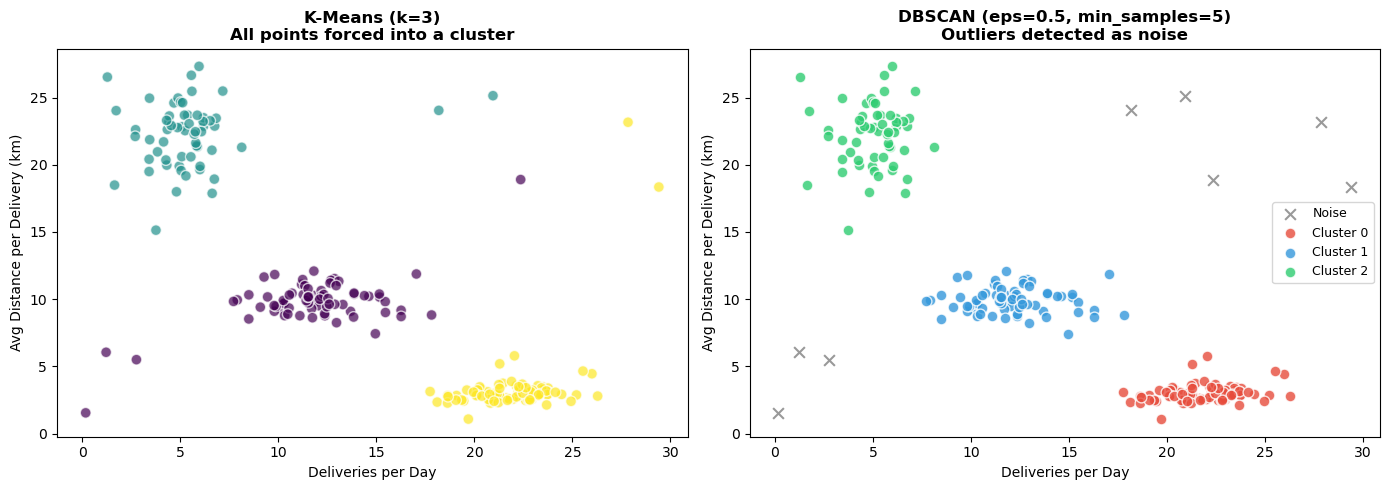

K-Means:  every outlier is silently absorbed into whichever cluster is nearest.
DBSCAN :  outliers are correctly identified and flagged as noise.


In [32]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: K-Means ─────────────────────────────────────────────────────
scatter = axes[0].scatter(df['deliveries_per_day'], df['avg_distance_km'],
                          c=kmeans_labels, cmap='viridis',
                          s=60, alpha=0.7, edgecolors='white')
axes[0].set_title('K-Means (k=3)\nAll points forced into a cluster',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Deliveries per Day')
axes[0].set_ylabel('Avg Distance per Delivery (km)')

# ── Right: DBSCAN ─────────────────────────────────────────────────────
# Colour clusters and noise differently
colours_map = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71', -1: 'grey'}
point_colours = [colours_map.get(l, 'black') for l in labels]
markers       = ['x' if l == -1 else 'o' for l in labels]

for l in sorted(set(labels)):
    mask = df['cluster'] == l
    name = 'Noise' if l == -1 else f'Cluster {l}'
    m    = 'x'     if l == -1 else 'o'
    axes[1].scatter(df.loc[mask, 'deliveries_per_day'],
                    df.loc[mask, 'avg_distance_km'],
                    c=colours_map.get(l, 'black'), marker=m,
                    s=60, alpha=0.8, edgecolors='white', label=name)

axes[1].set_title('DBSCAN (eps=0.5, min_samples=5)\nOutliers detected as noise',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Deliveries per Day')
axes[1].set_ylabel('Avg Distance per Delivery (km)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("K-Means:  every outlier is silently absorbed into whichever cluster is nearest.")
print("DBSCAN :  outliers are correctly identified and flagged as noise.")

## Step 8 — Interpret the Results

In [15]:
# Summarise each cluster using original (unscaled) feature values
cluster_summary = (
    df[df['cluster'] != -1]          # exclude noise
    .groupby('cluster')[['deliveries_per_day', 'avg_distance_km']]
    .mean()
    .round(1)
)
cluster_summary['count'] = df[df['cluster'] != -1].groupby('cluster')['cluster'].count()

print("Cluster Profiles (noise excluded):")
print(cluster_summary)
print(f"\nNoise points : {(df['cluster'] == -1).sum()}  (flagged as outliers — no cluster assigned)")

Cluster Profiles (noise excluded):
         deliveries_per_day  avg_distance_km  count
cluster                                            
0                      21.9              3.0     84
1                      12.0              9.9     70
2                       5.0             22.2     58

Noise points : 8  (flagged as outliers — no cluster assigned)


In [16]:
# Give each cluster a meaningful label based on the means
# (Adjust the mapping to match what your summary shows)

driver_labels = {}
for seg, row in cluster_summary.iterrows():
    if row['deliveries_per_day'] > 18:
        driver_labels[seg] = 'City Drivers'
    elif row['avg_distance_km'] > 18:
        driver_labels[seg] = 'Rural Drivers'
    else:
        driver_labels[seg] = 'Suburban Drivers'

cluster_summary['driver_type'] = cluster_summary.index.map(driver_labels)
print(cluster_summary[['driver_type', 'deliveries_per_day', 'avg_distance_km', 'count']])

              driver_type  deliveries_per_day  avg_distance_km  count
cluster                                                              
0            City Drivers                21.9              3.0     84
1        Suburban Drivers                12.0              9.9     70
2           Rural Drivers                 5.0             22.2     58


**`cluster_summary['driver_type'] = cluster_summary.index.map(driver_labels)`**

```

cluster_summary.index - the cluster numbers — 0, 1, 2 — because we grouped by 'cluster' earlier. So .index gives you [0, 1, 2].

.map(driver_labels) - takes each value in the index and looks it up in the driver_labels dictionary:

driver_labels = {0: 'City Drivers', 1: 'Suburban Drivers', 2: 'Rural Drivers'}

So it replaces:

0 → 'City Drivers'
1 → 'Suburban Drivers'
2 → 'Rural Drivers'

Think of .map() as saying: "for each value, find its match in this dictionary and return the corresponding value."

cluster_summary['driver_type'] = ... assigns the result as a new column called 'driver_type' in the DataFrame.

```

## Summary - DBSCAN workflow

```
1. Load and understand the data
2. Scale features with StandardScaler
3. Choose min_samples = 2 × number of features (start with 5 for 2D data)
4. Use the k-distance plot to find a good eps (look for the elbow)
5. Fit:  dbscan = DBSCAN(eps=..., min_samples=...)
         labels = dbscan.fit_predict(X_scaled)
6. Inspect:  labels == -1  → noise points
7. Interpret each cluster using mean feature values
8. Tune eps if the number of clusters or noise looks wrong
```

### When to choose DBSCAN over K-Means

| Situation | Better choice |
|-----------|---------------|
| You don't know how many clusters exist | **DBSCAN** |
| Clusters are irregular or curved shapes | **DBSCAN** |
| You need outliers to be flagged | **DBSCAN** |
| Clusters are round and roughly equal size | **K-Means** |
| Dataset is very large (speed matters) | **K-Means** |
